In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

df = pd.read_csv("../data/processed/master_data_clean.csv", parse_dates=["Date"])
df.shape

(852, 31)

## Revenue over time (the headline chart)

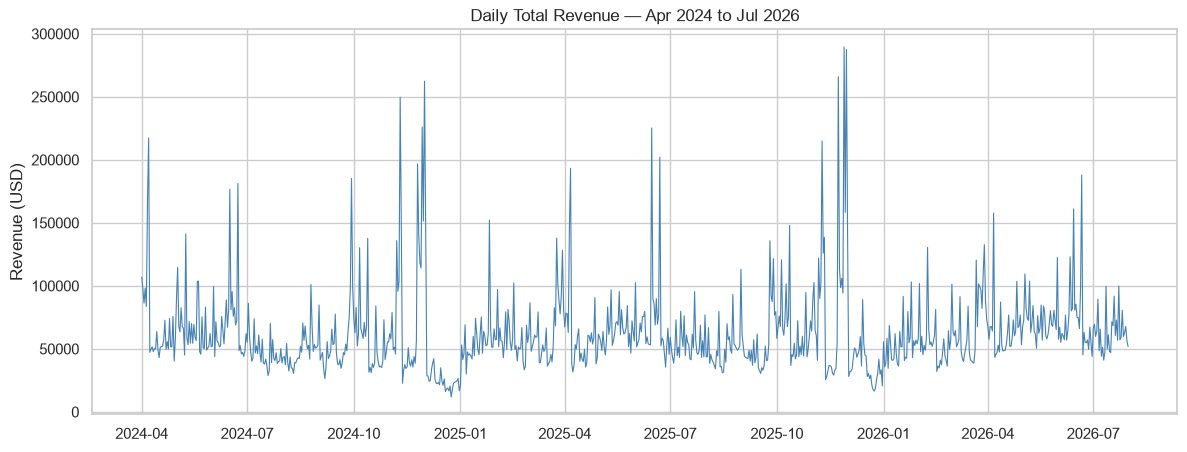

In [2]:
fig, ax = plt.subplots()
ax.plot(df["Date"], df["Total_Revenue"], linewidth=0.8, color="steelblue")
ax.set_title("Daily Total Revenue — Apr 2024 to Jul 2026")
ax.set_ylabel("Revenue (USD)")
plt.show()

## Revenue by month (seasonality, smoothed)

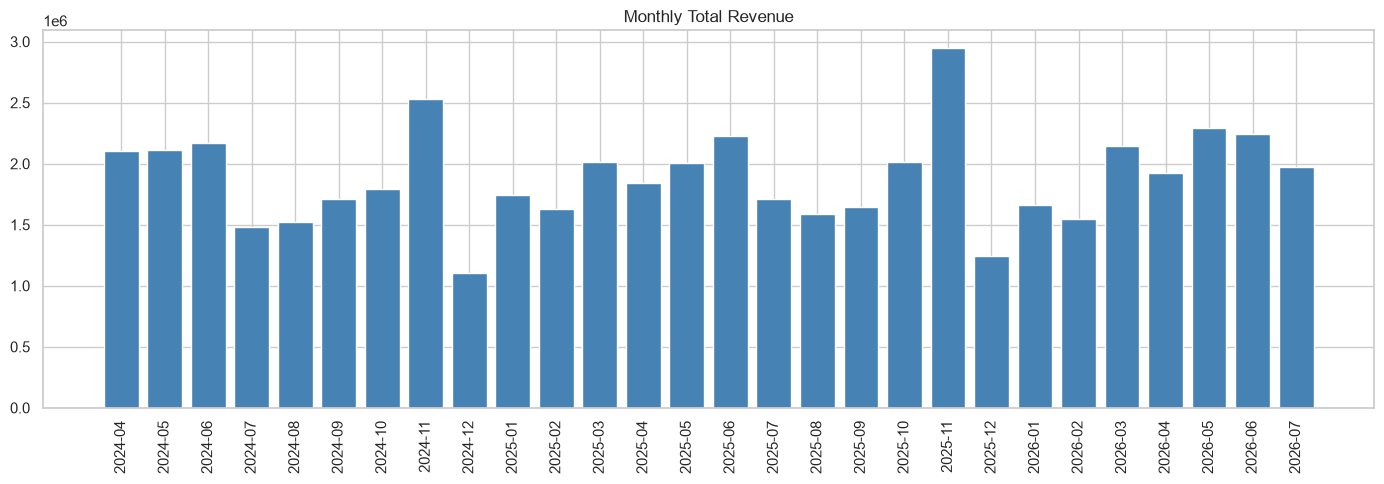

In [3]:
monthly = df.groupby("YearMonth", as_index=False)["Total_Revenue"].sum()
fig, ax = plt.subplots()
ax.bar(monthly["YearMonth"], monthly["Total_Revenue"], color="steelblue")
ax.set_title("Monthly Total Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Promo/mailing lift (does the flag actually move revenue?)

In [4]:
for flag in ["Promotion_Discount", "UWG_Mailing", "Offline_Promo", "holiday_list", "BFCM_Promo_Effect"]:
    comparison = df.groupby(flag)["Total_Revenue"].agg(["mean", "median", "count"])
    comparison["lift_vs_off_pct"] = (
        (comparison.loc[1, "mean"] - comparison.loc[0, "mean"]) / comparison.loc[0, "mean"] * 100
    )
    print(f"\n{flag}:\n{comparison}")


Promotion_Discount:
                            mean   median  count  lift_vs_off_pct
Promotion_Discount                                               
0                   49994.430143  47741.0    280        36.040337
1                   68012.591434  58413.0    572        36.040337

UWG_Mailing:
                      mean    median  count  lift_vs_off_pct
UWG_Mailing                                                 
0             56768.161869  52593.50    776       105.117503
1            116441.435921  94316.61     76       105.117503

Offline_Promo:
                       mean   median  count  lift_vs_off_pct
Offline_Promo                                               
0              57762.426186  52051.0    700        42.005722
1              82025.950066  72968.5    152        42.005722

holiday_list:
                      mean   median  count  lift_vs_off_pct
holiday_list                                               
0             61497.862044  53846.0    812        20.548043
1 

## New-customer revenue as a share of total

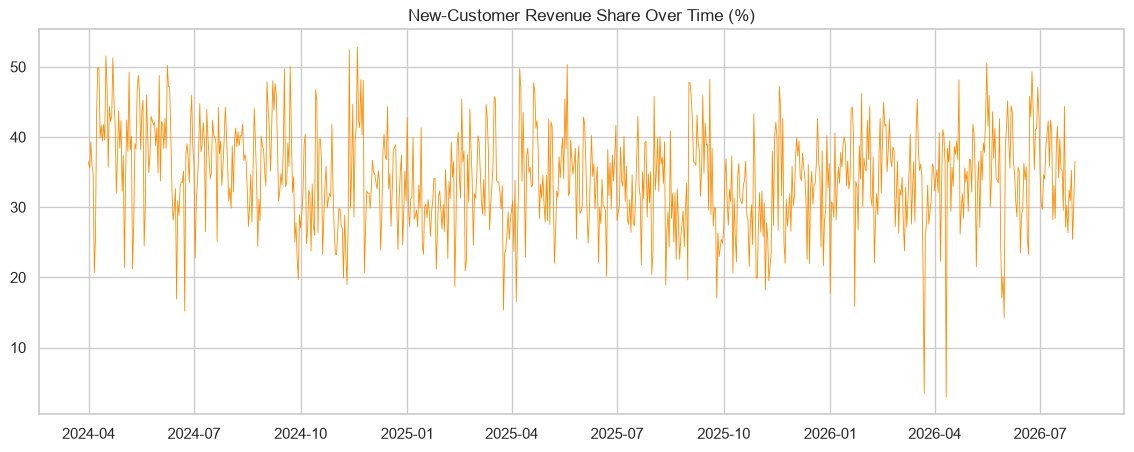

count    852.000000
mean      34.128112
std        7.107465
min        2.952200
25%       29.591827
50%       34.078683
75%       38.984585
max       52.826998
Name: New_Customer_Share, dtype: float64

In [5]:
df["New_Customer_Share"] = df["Revenue_New_Customer"] / df["Total_Revenue"] * 100

fig, ax = plt.subplots()
ax.plot(df["Date"], df["New_Customer_Share"], linewidth=0.6, color="darkorange")
ax.set_title("New-Customer Revenue Share Over Time (%)")
plt.show()

df["New_Customer_Share"].describe()

## Media spend mix over time

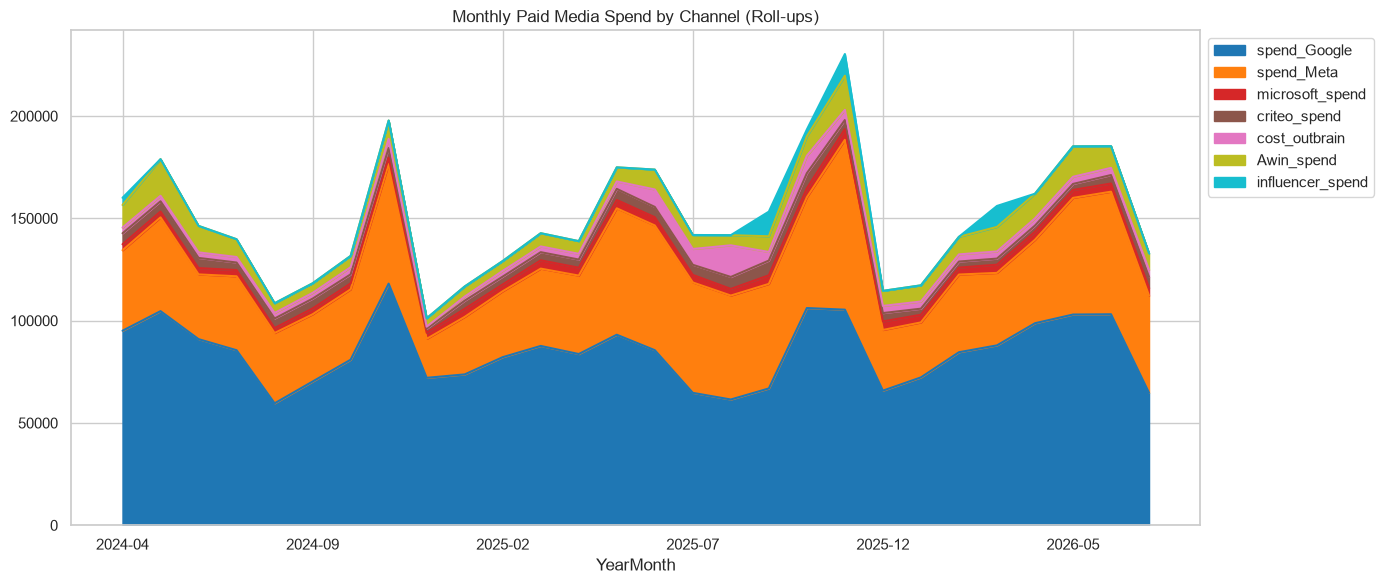

In [6]:
spend_cols = ["spend_Google", "spend_Meta", "microsoft_spend", "criteo_spend",
              "cost_outbrain", "Awin_spend", "influencer_spend"]

monthly_spend = df.groupby("YearMonth")[spend_cols].sum()
monthly_spend.plot.area(figsize=(14, 6), colormap="tab10")
plt.title("Monthly Paid Media Spend by Channel (Roll-ups)")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## Media efficiency: spend vs revenue

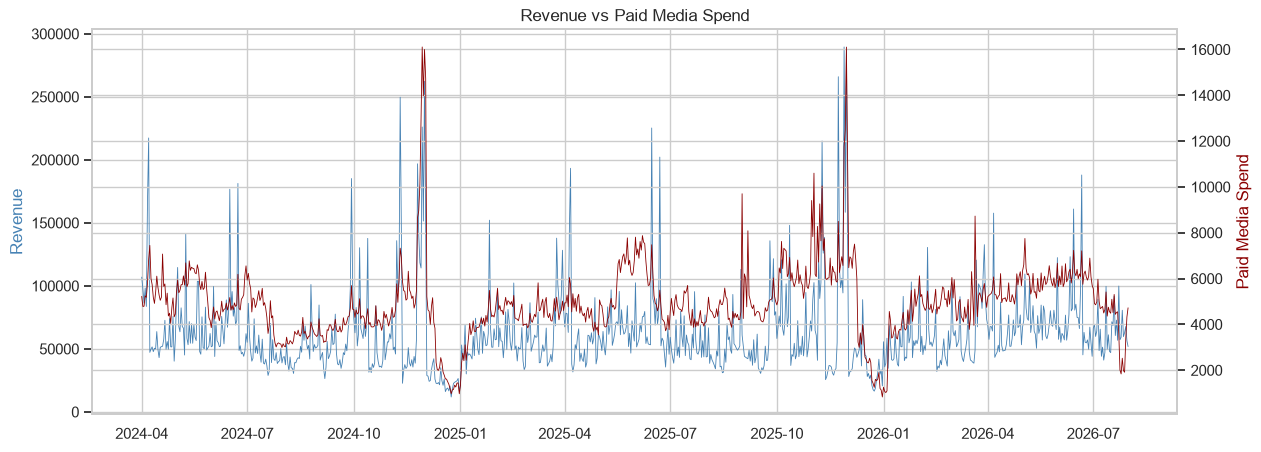

Avg Media % of Revenue: 8.83%


In [7]:
fig, ax1 = plt.subplots()
ax1.plot(df["Date"], df["Total_Revenue"], color="steelblue", linewidth=0.6, label="Revenue")
ax1.set_ylabel("Revenue", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(df["Date"], df["Total_Paid_Media"], color="darkred", linewidth=0.6, label="Paid Media Spend")
ax2.set_ylabel("Paid Media Spend", color="darkred")

plt.title("Revenue vs Paid Media Spend")
plt.show()

print(f"Avg Media % of Revenue: {df['Media_Pct_of_Revenue'].mean():.2f}%")

## correlation matrix (quick relationship scan)

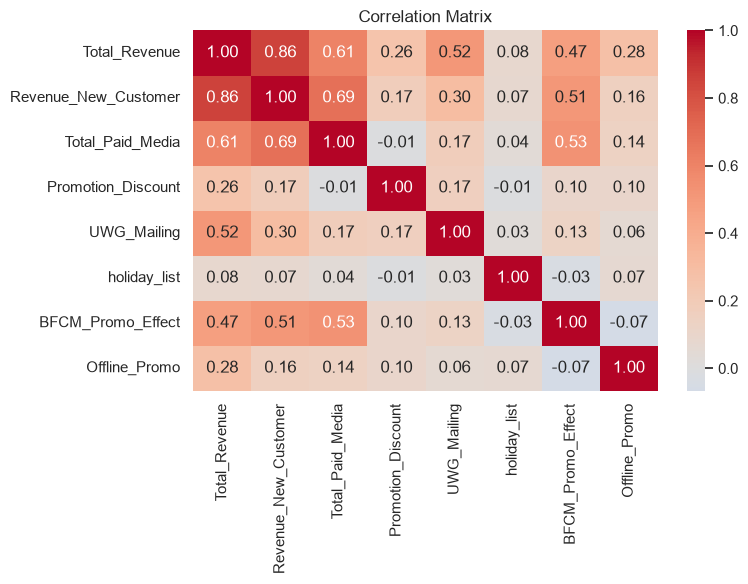

In [8]:
corr_cols = ["Total_Revenue", "Revenue_New_Customer", "Total_Paid_Media",
             "Promotion_Discount", "UWG_Mailing", "holiday_list",
             "BFCM_Promo_Effect", "Offline_Promo"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()